<a href="https://colab.research.google.com/github/gimdiniz/datathon-fase-5-passos-magicos/blob/main/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória

## 1. Imports Iniciais

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [45]:
import warnings
warnings.filterwarnings("ignore")

## 2. Padronização de Gráficos

In [46]:
#Paleta inspirada na identidade visual da Passos Mágicos
paleta_passos = {
    "fundo": "#F8FAFC",   # Fundo levemente acinzentado
    "texto": "#1E293B",   # Azul escuro/cinza
    "grid": "#E2E8F0",    # Grid suave
    "cor_1": "#1E3A8A",   # Azul Escuro
    "cor_2": "#F97316",   # Laranja
    "cor_3": "#FBBF24",   # Amarelo/Dourado
    "cor_4": "#10B981",   # Verde (Crescimento)
    "cor_5": "#8B5CF6",   # Roxo (Criatividade)
    "cor_6": "#38BDF8",   # Azul Claro (Juventude / Horizonte)
    "cor_7": "#F43F5E",   # Rosa/Coral (Empatia / Acolhimento social)
    "extra": "#6366F1",   # Índigo (Para destaques adicionais)
}

# Lista específica para categorias do projeto educacional
lista_cores_educacao = [
    paleta_passos["cor_1"], paleta_passos["cor_2"], paleta_passos["cor_3"],
    paleta_passos["cor_4"], paleta_passos["cor_5"], paleta_passos["cor_6"], paleta_passos["cor_7"]
]

# Define o tema global do Seaborn
sns.set_theme(
    style="whitegrid",
    # Paleta Padrão atualizada
    palette=lista_cores_educacao,

    rc={
        "figure.facecolor": paleta_passos["fundo"],
        "axes.facecolor": paleta_passos["fundo"],
        "axes.edgecolor": paleta_passos["grid"],
        "grid.color": paleta_passos["grid"],
        "text.color": paleta_passos["texto"],
        "axes.labelcolor": paleta_passos["texto"],
        "xtick.color": paleta_passos["texto"],
        "ytick.color": paleta_passos["texto"],
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

## 3. Carregamento da Base Tratada

In [47]:

url_do_git = "https://github.com/gimdiniz/datathon-fase-5-passos-magicos/raw/refs/heads/main/data/processed/passos_magicos_clean_eda.csv"

df = pd.read_csv(url_do_git)
df.head()

,Nota_Matematica,IAA,Fase Ideal,Turma,RA,INDE,Nota_Portugues,IDA,IAN,Ano Nascimento,IPV,IPS,Ano ingresso,Pedra,Instituição de ensino,Nome Anonimizado,IEG,Idade,Fase,Defasagem,Gênero,Ano_Referencia,IPP
0,2.7000,8.3000,Fase 8 (Universitários),A,RA-1,5.7830,3.5000,4.0000,5.0000,2003,7.2780,5.6000,2016,Quartzo,Escola Pública,Aluno-1,4.1000,19,FASE 7,-1,Feminino,2022,NaN
1,6.3000,8.8000,Fase 7 (3º EM),A,RA-2,7.0550,4.5000,6.8000,10.0000,2005,6.7780,6.3000,2017,Ametista,Rede Decisão,Aluno-2,5.2000,17,FASE 7,0,Feminino,2022,NaN
2,5.8000,0.0000,Fase 7 (3º EM),A,RA-3,6.5910,4.0000,5.6000,10.0000,2005,7.5560,5.6000,2016,Ágata,Rede Decisão,Aluno-3,7.9000,17,FASE 7,0,Feminino,2022,NaN
3,2.8000,8.8000,Fase 7 (3º EM),A,RA-4,5.9510,3.5000,5.0000,10.0000,2005,5.2780,5.6000,2017,Quartzo,Rede Decisão,Aluno-4,4.5000,17,FASE 7,0,Masculino,2022,NaN
4,7.0000,7.9000,Fase 7 (3º EM),A,RA-5,7.4270,2.9000,5.2000,10.0000,2005,7.3890,5.6000,2016,Ametista,Rede Decisão,Aluno-5,8.6000,17,FASE 7,0,Feminino,2022,NaN


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Nota_Matematica        2845 non-null   float64
 1   IAA                    2845 non-null   float64
 2   Fase Ideal             2845 non-null   object 
 3   Turma                  2845 non-null   object 
 4   RA                     2845 non-null   object 
 5   INDE                   2845 non-null   float64
 6   Nota_Portugues         2845 non-null   float64
 7   IDA                    2845 non-null   float64
 8   IAN                    2845 non-null   float64
 9   Ano Nascimento         2845 non-null   int64  
 10  IPV                    2845 non-null   float64
 11  IPS                    2845 non-null   float64
 12  Ano ingresso           2845 non-null   int64  
 13  Pedra                  2845 non-null   object 
 14  Instituição de ensino  2845 non-null   object 
 15  Nome

## Fundações e Evolução Temporal

###Distribuição do IAN

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

O indicador IAN traduz a defasagem dos alunos, podendo ser traduzida da seguinte forma:

2,5 = Severa
5 = Moderada
10 = Em Fase

--- Volumetria Absoluta de Alunos por Nível de IAN ---


IAN_Desc,Severa (2.5),Moderada (5.0),Em Fase (10.0)
Ano_Referencia,,,
2022,28,573,259
2023,13,531,387
2024,3,531,520



--- Percentual (%) de Alunos por Nível de IAN ---


IAN_Desc,Severa (2.5),Moderada (5.0),Em Fase (10.0)
Ano_Referencia,,,
2022,3.2600,66.6300,30.1200
2023,1.4000,57.0400,41.5700
2024,0.2800,50.3800,49.3400


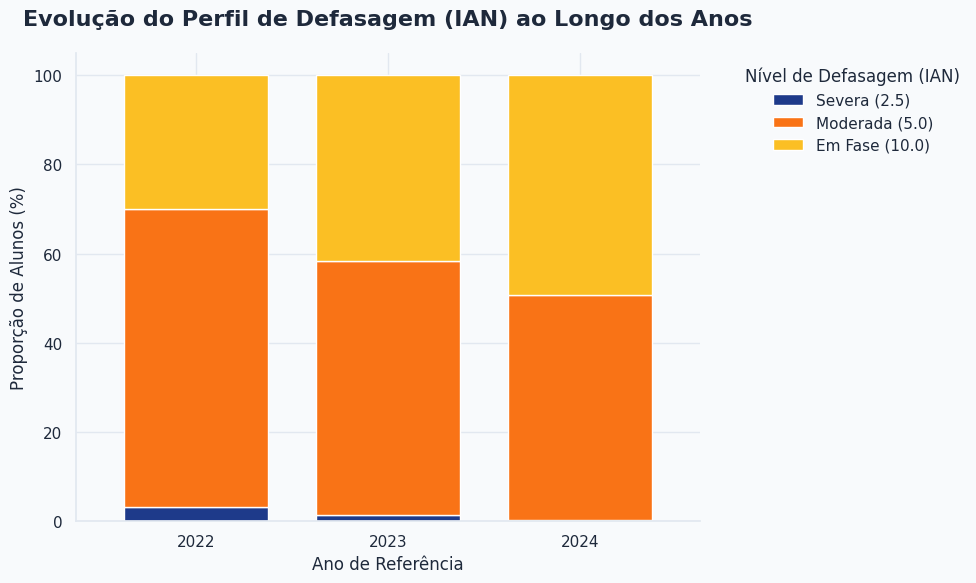

In [49]:
# Dicionário de-para (mapeamento)
dicionario_ian = {
    2.5: "Severa (2.5)",
    5.0: "Moderada (5.0)",
    10.0: "Em Fase (10.0)"
}

# Cria uma nova coluna descritiva, preservando a coluna numérica original
df['IAN_Desc'] = df['IAN'].map(dicionario_ian)

# Define a ordem desejada para as tabelas e para o gráfico
ordem_ian = ["Severa (2.5)", "Moderada (5.0)", "Em Fase (10.0)"]

# Quantos alunos em cada nível de IAN por ano?
tabela_ian_abs = pd.crosstab(df['Ano_Referencia'], df['IAN_Desc'])
tabela_ian_abs = tabela_ian_abs.reindex(columns=ordem_ian) # Força a ordem lógica
print("--- Volumetria Absoluta de Alunos por Nível de IAN ---")
display(tabela_ian_abs)

# Qual a proporção de cada nível de defasagem por ano?
tabela_ian_pct = pd.crosstab(df['Ano_Referencia'], df['IAN_Desc'], normalize='index') * 100
tabela_ian_pct = tabela_ian_pct.reindex(columns=ordem_ian) # Força a ordem lógica
print("\n--- Percentual (%) de Alunos por Nível de IAN ---")
display(tabela_ian_pct.round(2))

fig, ax = plt.subplots(figsize=(10, 6))

# Plotando os dados percentuais
# Selecionamos as 3 primeiras cores da sua lista para bater com as 3 categorias
tabela_ian_pct.plot(
    kind='bar',
    stacked=True,
    color=lista_cores_educacao[:3],
    ax=ax,
    width=0.75
)

# Ajustes do gráfico
plt.title('Evolução do Perfil de Defasagem (IAN) ao Longo dos Anos',
          fontsize=16, pad=20, weight='bold')
plt.xlabel('Ano de Referência', fontsize=12)
plt.ylabel('Proporção de Alunos (%)', fontsize=12)

# Ajuste da legenda
plt.legend(title='Nível de Defasagem (IAN)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Em 2022, a fotografia da ONG mostrava que a grande maioria dos alunos estava em algum grau de defasagem (66,63% moderada + 3,26% seversa). Em 2024, o cenário muda radicalmente, e os alunos "Em Fase" passam a representar praticamente 50% do total. A ONG deixou de ser um ambiente majoritariamente de "recuperação" para se tornar um ambiente de "manutenção" do conhecimento.

Isso gera uma segunda pergunta. Será que o perfil dos alunos mudou ao longo dos anos ou de fato um mesmo aluno teve uma evolução no nível de defasagem?

Total de alunos únicos na base geral: 1586
Total de alunos longitudinais (presentes em todos os 3 anos): 434

--- Resumo da Evolução (IAN): 2022 vs 2024 ---


,Quantidade,Percentual (%)
Status_Evolucao,,
Manteve,245,56.4500
Reduziu Defasagem,159,36.6400
Aumentou Defasagem,30,6.9100



--- Matriz de Transição de Alunos: Onde estavam e para onde foram ---


IAN 2024 (Ponto de Chegada),Severa (2.5),Moderada (5.0),Em Fase (10.0)
IAN 2022 (Ponto de Partida),,,
Severa (2.5),0,4,2
Moderada (5.0),2,128,153
Em Fase (10.0),0,28,117


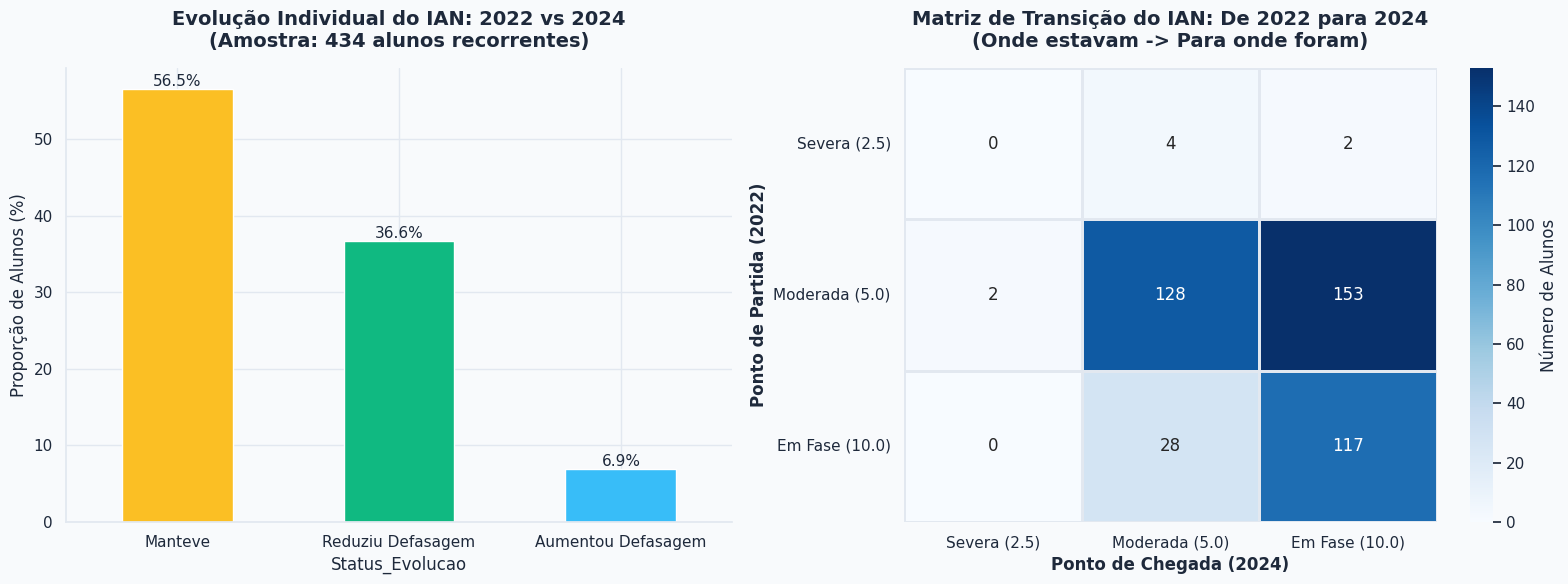

In [50]:
# 1. Identificar os anos disponíveis e filtrar os alunos "longitudinais"
anos_disponiveis = df['Ano_Referencia'].unique()
# Conta em quantos anos distintos cada RA aparece
ra_por_ano = df.groupby('RA')['Ano_Referencia'].nunique()
# Filtra apenas os RAs que aparecem em todos os anos
ras_presentes_todos_anos = ra_por_ano[ra_por_ano == len(anos_disponiveis)].index

# Cria um novo DataFrame apenas com esses alunos
df_longitudinal = df[df['RA'].isin(ras_presentes_todos_anos)]

print(f"Total de alunos únicos na base geral: {df['RA'].nunique()}")
print(f"Total de alunos longitudinais (presentes em todos os {len(anos_disponiveis)} anos): {len(ras_presentes_todos_anos)}\n")

# 2. Pivotar os dados para colocar os anos nas colunas e os RAs nas linhas
df_pivot = df_longitudinal.pivot(index='RA', columns='Ano_Referencia', values='IAN')

ano_inicial = df_pivot.columns.min()
ano_final = df_pivot.columns.max()

# 3. Classificar a evolução
def classificar_evolucao(row):
    if row[ano_final] > row[ano_inicial]:
        return 'Reduziu Defasagem'
    elif row[ano_final] < row[ano_inicial]:
        return 'Aumentou Defasagem'
    else:
        return 'Manteve'

df_pivot['Status_Evolucao'] = df_pivot.apply(classificar_evolucao, axis=1)

# 4. Resumo da Evolução
resumo_evolucao = df_pivot['Status_Evolucao'].value_counts()
resumo_pct = df_pivot['Status_Evolucao'].value_counts(normalize=True) * 100

print(f"--- Resumo da Evolução (IAN): {ano_inicial} vs {ano_final} ---")
display(pd.DataFrame({'Quantidade': resumo_evolucao, 'Percentual (%)': resumo_pct.round(2)}))

# 5. Matriz de Transição (De -> Para)
dicionario_ian = {2.5: "Severa (2.5)", 5.0: "Moderada (5.0)", 10.0: "Em Fase (10.0)"}

matriz_transicao = pd.crosstab(
    df_pivot[ano_inicial].map(dicionario_ian),
    df_pivot[ano_final].map(dicionario_ian),
    rownames=[f'IAN {ano_inicial} (Ponto de Partida)'],
    colnames=[f'IAN {ano_final} (Ponto de Chegada)']
)

# Forçando a ordem lógica para garantir que a matriz fique alinhada corretamente
ordem_ian = ["Severa (2.5)", "Moderada (5.0)", "Em Fase (10.0)"]
matriz_transicao = matriz_transicao.reindex(index=ordem_ian, columns=ordem_ian, fill_value=0)

print(f"\n--- Matriz de Transição de Alunos: Onde estavam e para onde foram ---")
display(matriz_transicao)

# Cria uma figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Barras de Status de Evolução (ax=axes[0]) ---
cores_status = {
    'Reduziu Defasagem': paleta_passos["cor_4"],
    'Manteve': paleta_passos["cor_3"],
    'Aumentou Defasagem': paleta_passos["cor_6"]
}
status_presentes = resumo_pct.index.tolist()
cores_plot = [cores_status[status] for status in status_presentes]

resumo_pct.plot(kind='bar', color=cores_plot, ax=axes[0])

axes[0].set_title(f'Evolução Individual do IAN: {ano_inicial} vs {ano_final}\n(Amostra: {len(ras_presentes_todos_anos)} alunos recorrentes)',
                  fontsize=14, pad=15, weight='bold')
axes[0].set_ylabel('Proporção de Alunos (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Adiciona o % em cima de cada barra
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, color=paleta_passos["texto"])

# --- Gráfico 2: Heatmap da Matriz de Transição (ax=axes[1]) ---
sns.heatmap(matriz_transicao, annot=True, fmt="d", cmap="Blues",
            cbar_kws={'label': 'Número de Alunos'}, ax=axes[1],
            linewidths=1, linecolor=paleta_passos["grid"])

axes[1].set_title(f'Matriz de Transição do IAN: De {ano_inicial} para {ano_final}\n(Onde estavam -> Para onde foram)',
                  fontsize=14, pad=15, weight='bold', color=paleta_passos["texto"])

axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)
axes[1].set_ylabel(f'Ponto de Partida ({ano_inicial})', fontsize=12, weight='bold')
axes[1].set_xlabel(f'Ponto de Chegada ({ano_final})', fontsize=12, weight='bold')

# Ajusta o espaçamento geral entre os gráficos para não encavalar
plt.tight_layout()
plt.show()

O maior destaque positivo da matriz de transição está no bloco de alunos que saíram da defasagem Moderada (5.0) em 2022 e alcançaram o nível Em Fase (10.0) em 2024. Foram 153 alunos que deram esse salto, representando a maioria do grupo de 36.6% que "Reduziu Defasagem". Isso comprova estatisticamente que o programa da ONG é altamente eficaz em recuperar alunos no nível moderado de defasagem.

Além disso, 117 alunos já estavam "Em Fase" em 2022 e continuaram "Em Fase" em 2024. Isso demonstra que o programa consegue fazer a manutenção de bons desempenhos.

Por outro lado, 128 alunos começaram na fase "Moderada" em 2022 e continuaram presos nela em 2024. Esse é o maior grupo isolado da matriz. O que falta para esses 128 alunos conseguirem o mesmo salto dos 153 que evoluíram?

Em 2022, haviam 6 alunos em defasagem severa. Desses, 4 evoluíram para Moderada e 2 saltaram direto para "Em Fase". Em 2024, apenas 2 alunos estão em defasagem severa (e eles caíram da fase Moderada). O programa praticamente erradicou o risco crítico nessa amostra.

Os 6.9% que "Aumentaram a Defasagem" são compostos quase que inteiramente por 28 alunos que estavam "Em Fase" e caíram para "Moderada" em 2024. Será que houve alguma queda de engajamento (IEG) ou problema psicossocial (IPS) que explique a queda de desempenho desses 28 alunos específicos?

###Tendência do IDA ao longo dos anos e fases educacionais

O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

O indicador IDA segue a seguinte fórmula:
IDA = (Nota Matemática + Nota Português + Nota Inglês) / 3

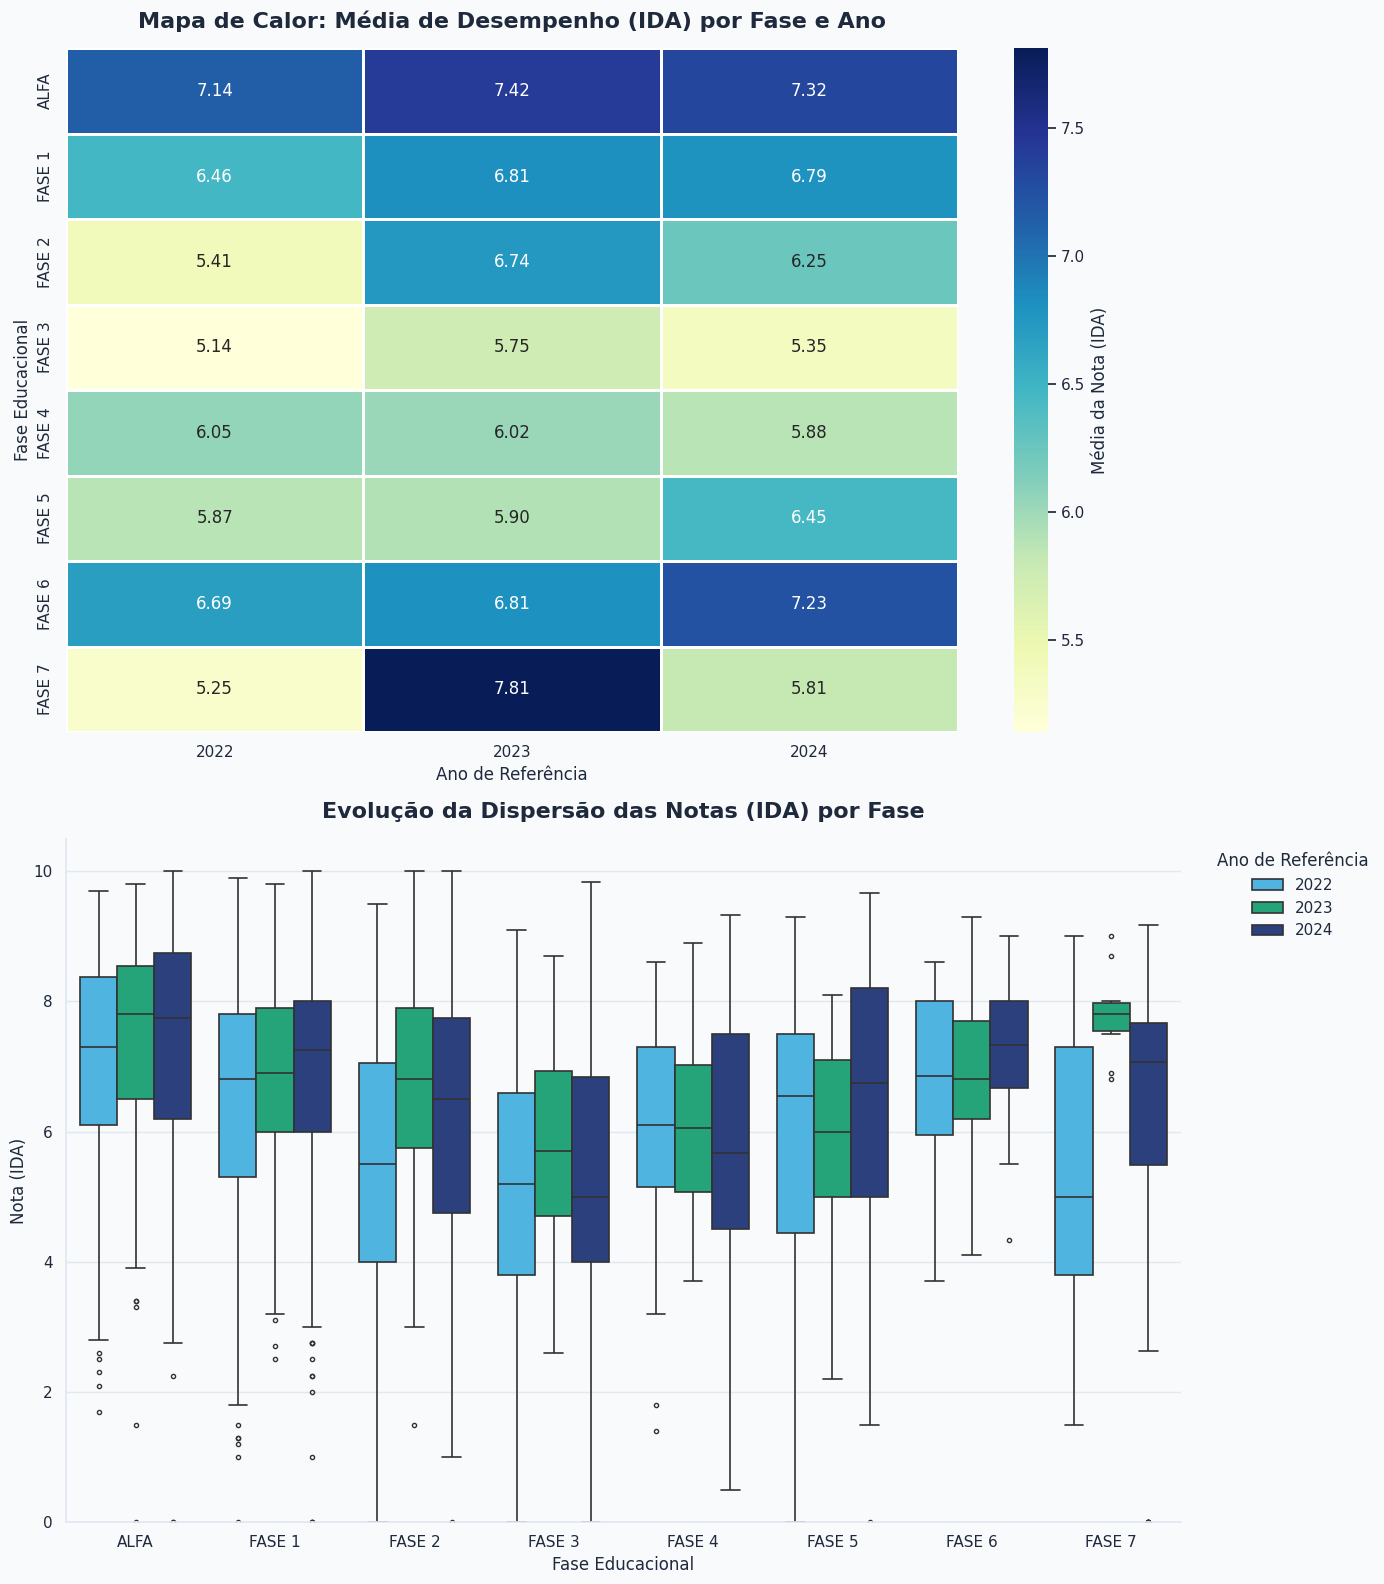

In [51]:
# 1. Prepara os dados para o Heatmap (Média do IDA)
# Linhas = Fase, Colunas = Ano, Valores = Média do IDA
tabela_ida_heatmap = df.pivot_table(index='Fase', columns='Ano_Referencia', values='IDA', aggfunc='mean')

ordem_fases = ['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7']

# Cria a figura
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# --- GRÁFICO 1: Heatmap das Médias ---
sns.heatmap(tabela_ida_heatmap, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=1, ax=axes[0], cbar_kws={'label': 'Média da Nota (IDA)'})

axes[0].set_title('Mapa de Calor: Média de Desempenho (IDA) por Fase e Ano',
                  fontsize=16, pad=15, weight='bold')
axes[0].set_ylabel('Fase Educacional', fontsize=12)
axes[0].set_xlabel('Ano de Referência', fontsize=12)

# --- GRÁFICO 2: Boxplot Agrupado por Fase ---
cores_anos = [paleta_passos["cor_6"], paleta_passos["cor_4"], paleta_passos["cor_1"]]

sns.boxplot(data=df, x='Fase', y='IDA', hue='Ano_Referencia', order=ordem_fases,
            palette=cores_anos, ax=axes[1], linewidth=1.2, fliersize=3)

axes[1].set_title('Evolução da Dispersão das Notas (IDA) por Fase',
                  fontsize=16, pad=15, weight='bold')
axes[1].set_xlabel('Fase Educacional', fontsize=12)
axes[1].set_ylabel('Nota (IDA)', fontsize=12)

# Ajuste da legenda e dos limites
axes[1].legend(title='Ano de Referência', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
axes[1].set_ylim(0, 10.5)

plt.tight_layout()
plt.show()

No mapa de calor, a zona intermediária chama a atenção: As médias de desempenho despencam quando os alunos chegam na FASE 3 (ficando na casa dos 5 pontos) e continuam baixas na FASE 4.

No Boxplot, a FASE 3 demonstra grande desigualdade, com alguns alunos indo bem e uma grande massa tirando notas muito baixas. Esse é o maior gargalo pedagógico do programa atualmente.

A fase ALFA demonstra médias mais altas, acima de 7 pontos, porém quando olhamos para a dispersão da fase ALFA, existe um pequeno grupo de crianças que está ficando completamente para trás e tirando notas críticas logo na fase de alfabetização/entrada. A FASE 1 também possui outliers e notas um pouco piores na média.

Outro ponto que também chama a atenção é a FASE 7, que teve um salto em 2023 (7.81), e média bem diferente de 2022 (5.25) e 2024 (5.81). O boxplot tem uma caixa "pequena", indicando que em 2023 a FASE 7 teve pouquíssimos alunos, ou que foi uma turma excepcionalmente nivelada por cima, por exemplo.

###Efetividade Geral do programa

Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

--- Média do Índice Global (INDE) por Pedra e Ano ---


Ano_Referencia,2022,2023,2024
Pedra,,,
Quartzo,5.2400,5.5500,5.4000
Ágata,6.6100,6.5700,6.6000
Ametista,7.5300,7.5100,7.5300
Topázio,8.3700,8.4400,8.4700


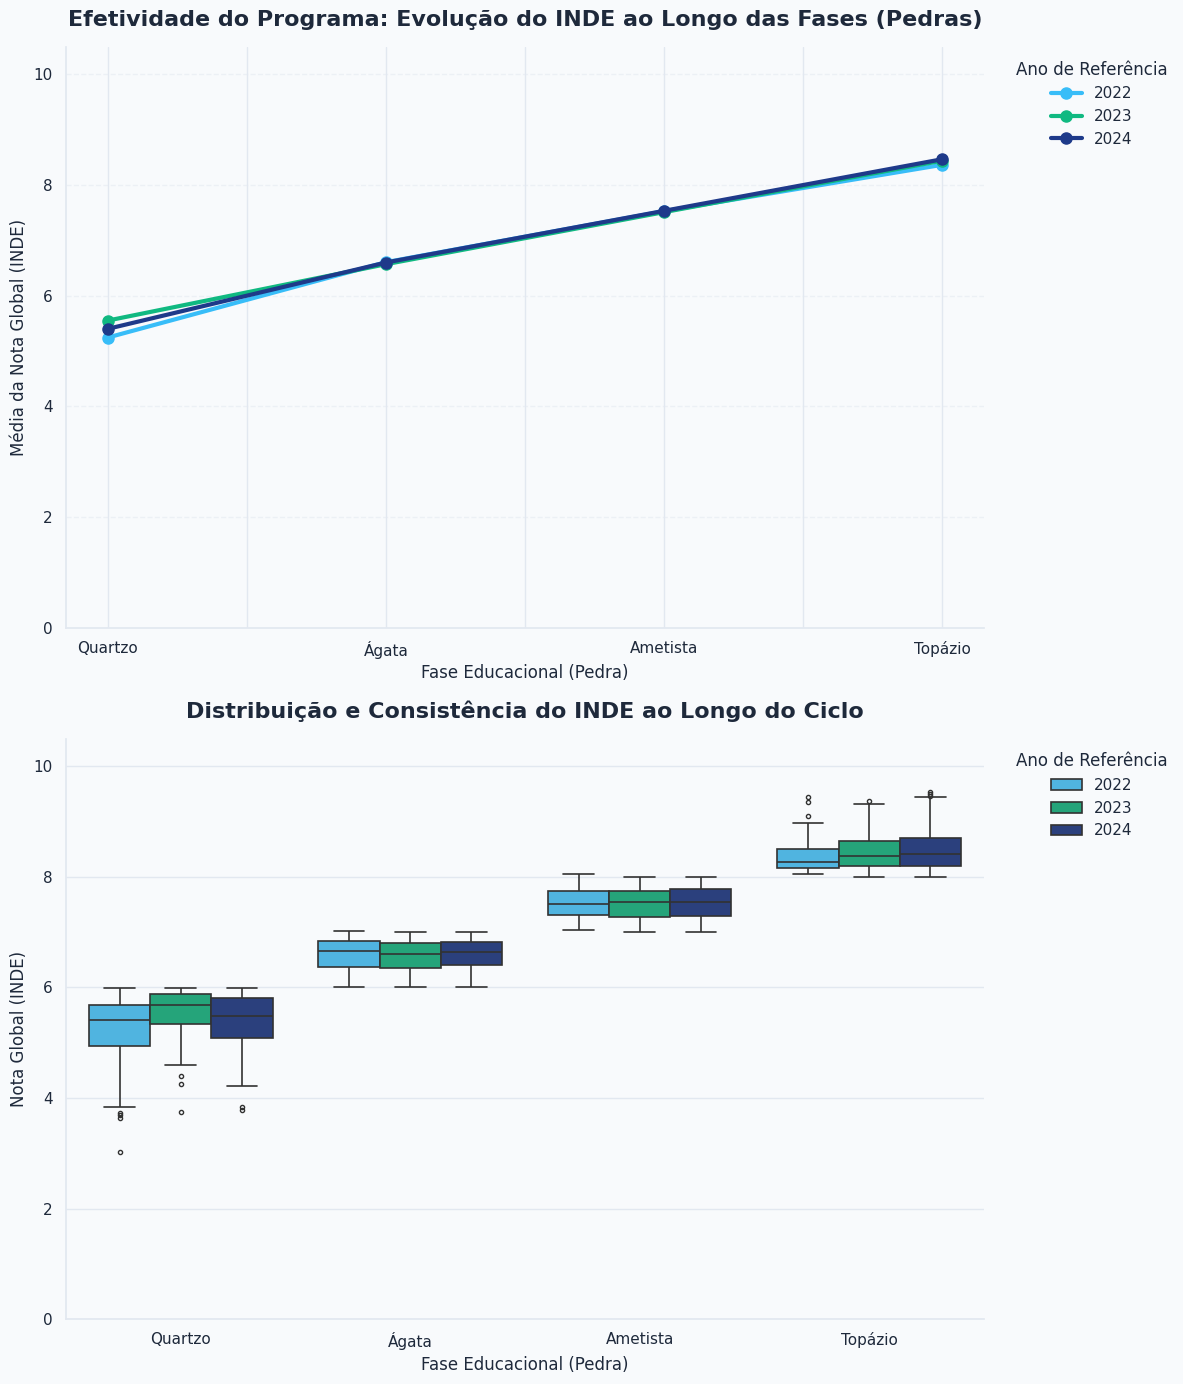

In [52]:
# Definir a ordem oficial do programa
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

# Calcular a média do INDE por Pedra e Ano
tabela_inde = df.pivot_table(index='Pedra', columns='Ano_Referencia', values='INDE', aggfunc='mean')

# Filtra e reordena apenas as pedras da nossa lista
pedras_presentes = [p for p in ordem_pedras if p in tabela_inde.index]
tabela_inde = tabela_inde.reindex(index=pedras_presentes)

print("--- Média do Índice Global (INDE) por Pedra e Ano ---")
display(tabela_inde.round(2))


# PLOTS

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Mantendo as cores contrastantes para os 3 anos (2022, 2023, 2024)
cores_anos = [paleta_passos["cor_6"], paleta_passos["cor_4"], paleta_passos["cor_1"]]

# --- Gráfico 1: Evolução do INDE ao longo das Pedras (Linhas por Ano) ---
tabela_inde.plot(kind='line', marker='o', linewidth=3, markersize=8,
                 color=cores_anos, ax=axes[0])

axes[0].set_title('Efetividade do Programa: Evolução do INDE ao Longo das Fases (Pedras)',
                  fontsize=16, pad=15, weight='bold', color=paleta_passos["texto"])
axes[0].set_ylabel('Média da Nota Global (INDE)', fontsize=12)
axes[0].set_xlabel('Fase Educacional (Pedra)', fontsize=12)
axes[0].set_ylim(0, 10.5)

axes[0].legend(title='Ano de Referência', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 2: Dispersão e Consistência do INDE por Pedra ---
# Cria um df temporário só com as pedras que queremos plotar para limpar o gráfico
df_plot = df[df['Pedra'].isin(pedras_presentes)]

sns.boxplot(data=df_plot, x='Pedra', y='INDE', hue='Ano_Referencia',
            order=pedras_presentes, palette=cores_anos, ax=axes[1], linewidth=1.2, fliersize=3)

axes[1].set_title('Distribuição e Consistência do INDE ao Longo do Ciclo',
                  fontsize=16, pad=15, weight='bold', color=paleta_passos["texto"])
axes[1].set_ylabel('Nota Global (INDE)', fontsize=12)
axes[1].set_xlabel('Fase Educacional (Pedra)', fontsize=12)
axes[1].set_ylim(0, 10.5)
axes[1].legend(title='Ano de Referência', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

O primeiro gráfico serve para uma análise de consistência já que, por definição, a classificação das pedras segue a referência o próprio INDE. Podemos identificar que as classificações estão adequadas e aderentes às premissas.

Já o Boxplot indica um comportamento muito consistente nas pedras Ágata e Ametista, que se mantém com uma amplitude e médias muito parecidas ao longo dos 3 anos analisados, com entregas de acordo com o esperado.

Para Quartzo, a amplitude de 2023 e 2024 reduziu em comparação a 2022, demonstrando menor desigualdade de notas. Ainda assim, nota-se a presença de alguns outliers em todos os anos, indicando que existem alunos nessa categoria que exigem intervenção imediata, por estarem muito descolados do limite inferior da classificação.

Já para Topázio, o comportamento é inverso: a variância aumentou ao longo dos  anos, indicando esse "teto" de notas sendo empurrado para cima. Além disso, também existem outliers que rendem ainda melhor do que a maioria.

##Cruzamentos e Comportamento

### Correlação entre Engajamento (IEG), Desempenho (IDA) e Ponto de Virada (IPV)

O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

Por definição:
IEG (Indicador de Engajamento) é uma dimensão acadêmica, que registra o engajamento do aluno nas entregas de lição de casa e voluntariado.


IDA (Indicador de Adequação de Nível) é uma dimensão acadêmica. Nas fases 0 a 7, registra a proficiência do aluno nos exames padronizados de avaliação interna das disciplinas; na fase 8, representa e a nota média obtida pelos alunos em todas as disciplinas curriculares cursadas nas respectivas instituições de ensino superior conveniadas ao programa de bolsas de estudo da Associação.

IPV (Indicador de Ponto de Virada) é uma dimensão psicopedagógica, resultado de questionário individual de avaliação dos pedagogos e professores sobre o desenvolvimento do alunos das aptidões necessárias para iniciar a transformação do aluno por meio da Educação, avaliando a integração à Passos Mágicos, desenvolvimento emocional e potencial acadêmico. Presente somente das fases 0 a 7.

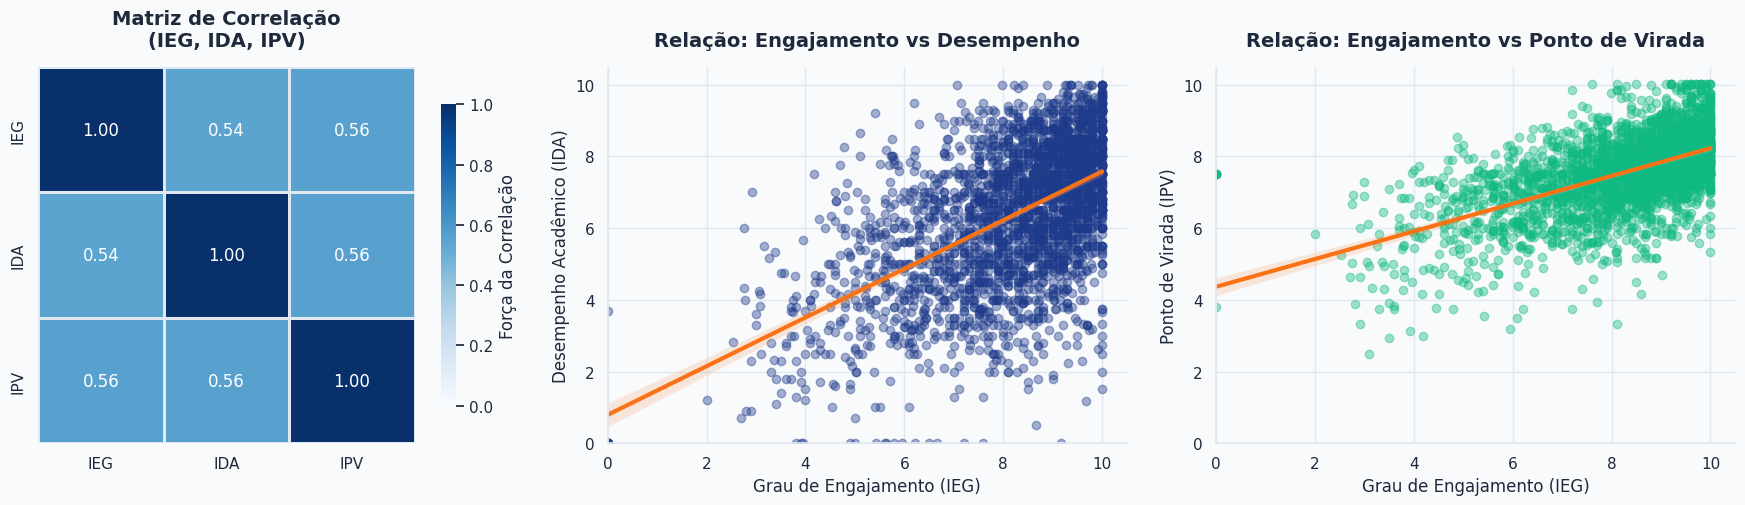

In [53]:
# Selecionando as colunas a serem analisadas
colunas_interesse = ['IEG', 'IDA', 'IPV']

# Cálculo da Matriz de Correlação
df_corr = df[colunas_interesse].dropna()
matriz_correlacao = df_corr.corr()

# PLOT
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Heatmap de Correlação
sns.heatmap(matriz_correlacao, annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, ax=axes[0], square=True,
            linewidths=1, linecolor=paleta_passos["grid"],
            cbar_kws={'shrink': 0.8, 'label': 'Força da Correlação'})

axes[0].set_title('Matriz de Correlação\n(IEG, IDA, IPV)',
                  fontsize=14, pad=15, weight='bold', color=paleta_passos["texto"])

# Gráfico 2: Scatter Plot (IEG vs IDA)
sns.regplot(data=df, x='IEG', y='IDA',
            scatter_kws={'alpha': 0.4, 'color': paleta_passos["cor_1"]},
            line_kws={'color': paleta_passos["cor_2"], 'linewidth': 3},
            ax=axes[1])

axes[1].set_title('Relação: Engajamento vs Desempenho',
                  fontsize=14, pad=15, weight='bold', color=paleta_passos["texto"])
axes[1].set_xlabel('Grau de Engajamento (IEG)', fontsize=12)
axes[1].set_ylabel('Desempenho Acadêmico (IDA)', fontsize=12)
axes[1].set_xlim(0, 10.5)
axes[1].set_ylim(0, 10.5)

# Gráfico 3: Scatter Plot (IEG vs IPV)
sns.regplot(data=df, x='IEG', y='IPV',
            scatter_kws={'alpha': 0.4, 'color': paleta_passos["cor_4"]},
            line_kws={'color': paleta_passos["cor_2"], 'linewidth': 3},
            ax=axes[2])

axes[2].set_title('Relação: Engajamento vs Ponto de Virada',
                  fontsize=14, pad=15, weight='bold', color=paleta_passos["texto"])
axes[2].set_xlabel('Grau de Engajamento (IEG)', fontsize=12)
axes[2].set_ylabel('Ponto de Virada (IPV)', fontsize=12)
axes[2].set_xlim(0, 10.5)
axes[2].set_ylim(0, 10.5)

plt.tight_layout()
plt.show()

Os valores no mapa de calor (0.54 e 0.56) indicam uma correlação positiva moderada entre todas as variáveis. Isso significa que quando o engajamento (IEG) do aluno sobe, a tendência é que as notas (IDA) e a maturidade emocional/psicopedagógica (IPV) subam junto.

O fato de o IPV ter uma correlação de 0.56 tanto com o IEG quanto com o IDA prova que a avaliação qualitativa dos pedagogos está alinhada com os dados quantitativos de esforço e nota. O "Ponto de Virada" é realmente reflexo do aluno se engajando e performando.

Já a análise de Engajamento (IEG) vs Desempenho (IDA) demonstra que alunos que entregam as lições e participam ativamente (IEG alto) tendem a tirar as melhores notas nos exames (IDA alto). Por outro lado, existem alguns pontos que estão no canto inferior direito do gráfico (IEG entre 8 e 10, mas IDA abaixo de 4). Esse grupo indica alunos que estão engajados nas atividades, porém seu desempenho não acompanha. Pode indicar necessidade de intervenções pedagógicas.

No gráfico de dispersão da direita, de relação entre Engajamento (IEG) vs Ponto de Virada (IPV), vemos que a nuvem de pontos acompanha a linha de tendência de forma um pouco mais "fiel" do que na análise vs Desempenho (IDA), especialmente nas notas mais altas.
Entregar as lições e participar das atividades voluntárias da Passos é o maior sinalizador visível de que o aluno está passando por uma transformação interna. Para os professores e pedagogos, um aluno que começa a entregar os trabalhos com consistência é um aluno que está absorvendo os valores da Passos Mágicos e desenvolvendo o potencial necessário.

Em resumo, fomentar o engajamento (IEG) é o centro do programa, pois ele traciona o aluno tanto em comportamento quanto em desempenho acadêmico/engajamento geral.

### Autoavaliação (IAA) vs Desempenho (IDA) e Engajamento (IEG)

As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)? Os alunos estão se subestimando, superestimando ou em linha?

Definição:
IAA (Indicador de Autoavaliação) é uma dimensão psicossocial, que registra por meio de um questionário, uma autoavaliação do aluno sobre como se sente consigo mesmo, estudos, sobre sua família, amigos, comunidade e com relação a Passos Mágicos.

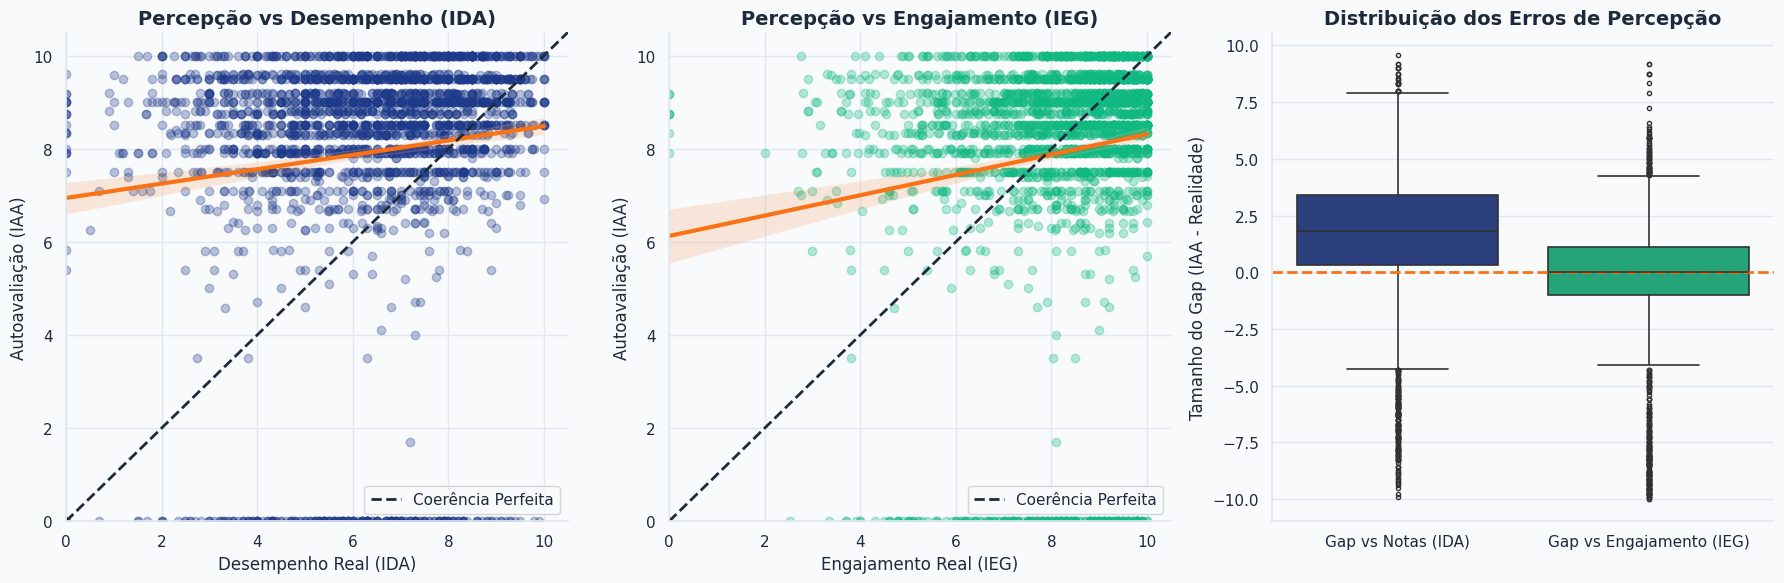

In [54]:
# Criando as métricas de Gap (Autoavaliação - Realidade)
df['Gap_IDA'] = df['IAA'] - df['IDA'] # Diferença para a Nota Real
df['Gap_IEG'] = df['IAA'] - df['IEG'] # Diferença para o Engajamento Real

# PLOT
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: IAA vs IDA (Percepção vs Nota Real)
sns.regplot(data=df, x='IDA', y='IAA',
            scatter_kws={'alpha': 0.3, 'color': paleta_passos["cor_1"]},
            line_kws={'color': paleta_passos["cor_2"], 'linewidth': 3}, ax=axes[0])

# Linha de referência perfeita (x = y)
axes[0].plot([0, 10.5], [0, 10.5], color=paleta_passos['texto'], linestyle='--', linewidth=2, label='Coerência Perfeita')
axes[0].set_title('Percepção vs Desempenho (IDA)', fontsize=14, weight='bold')
axes[0].set_xlabel('Desempenho Real (IDA)', fontsize=12)
axes[0].set_ylabel('Autoavaliação (IAA)', fontsize=12)
axes[0].set_xlim(0, 10.5)
axes[0].set_ylim(0, 10.5)
axes[0].legend(loc='lower right')

# Gráfico 2: IAA vs IEG (Percepção vs Engajamento)
sns.regplot(data=df, x='IEG', y='IAA',
            scatter_kws={'alpha': 0.3, 'color': paleta_passos["cor_4"]},
            line_kws={'color': paleta_passos["cor_2"], 'linewidth': 3}, ax=axes[1])

# Linha de referência perfeita (x = y)
axes[1].plot([0, 10.5], [0, 10.5], color=paleta_passos['texto'], linestyle='--', linewidth=2, label='Coerência Perfeita')
axes[1].set_title('Percepção vs Engajamento (IEG)', fontsize=14, weight='bold')
axes[1].set_xlabel('Engajamento Real (IEG)', fontsize=12)
axes[1].set_ylabel('Autoavaliação (IAA)', fontsize=12)
axes[1].set_xlim(0, 10.5)
axes[1].set_ylim(0, 10.5)
axes[1].legend(loc='lower right')

# Gráfico 3: Comparação Direta dos Gaps (Boxplot)
# Preparando os dados para plotar os Gaps lado a lado
df_gaps = df[['Gap_IDA', 'Gap_IEG']].melt(var_name='Tipo de Gap', value_name='Valor do Gap')

sns.boxplot(data=df_gaps, x='Tipo de Gap', y='Valor do Gap',
            palette=[paleta_passos["cor_1"], paleta_passos["cor_4"]], ax=axes[2],
            linewidth=1.2, fliersize=3)

# Linha do zero absoluto (onde a expectativa bate perfeitamente com a realidade)
axes[2].axhline(0, color=paleta_passos['cor_2'], linestyle='--', linewidth=2)
axes[2].set_title('Distribuição dos Erros de Percepção', fontsize=14, weight='bold')
axes[2].set_xticklabels(['Gap vs Notas (IDA)', 'Gap vs Engajamento (IEG)'])
axes[2].set_xlabel('')
axes[2].set_ylabel('Tamanho do Gap (IAA - Realidade)', fontsize=12)

plt.tight_layout()
plt.show()

No primeiro gráfico de dispersão (Percepção vs Desempenho), temos um bloco imenso de alunos com IDA real entre 4 e 6 que estão se avaliando com IAA entre 8 e 10. Isso demonstra um grande ponto cego: as crianças não têm clareza das suas próprias lacunas de aprendizado nas disciplinas.

O segundo gráfico (Percepção vs Engajamento) explica o porquê do ponto cego acontecer. A nuvem verde se aproxima muito mais a linha de coerência e tem um "congestionamento" enorme no canto superior direito (Engajamento 10, Autoavaliação 10). Pode ser um bom indicativo de que o aluno constrói a sua autoavaliação (IAA) baseada no próprio engajamento (IEG).

Essa suposição ainda é reforçada no boxpolot. A distribuição dos erros de percepção expõe que a percepção do aluno sobre si (IAA) está quase que diretamente ligada ao seu esforço (IEG) para entregas de lições/voluntariado, com uma mediana exatamente na linha do zero. Realidade que não acontece com relação às notas, com a caixa inteiramente deslocada para cima, demonstrando uma percepção maior vs o que de fato desempenham nas provas.

###Avanço entre Pedras e melhora na aderência entre autoavaliação (IAA) e desempenho real

O resultado da análise anterior nos leva a uma nova pergunta. Será que, com a evolução entre as fases, os alunos melhoram a aderência entre autopercepção e desempenho real?

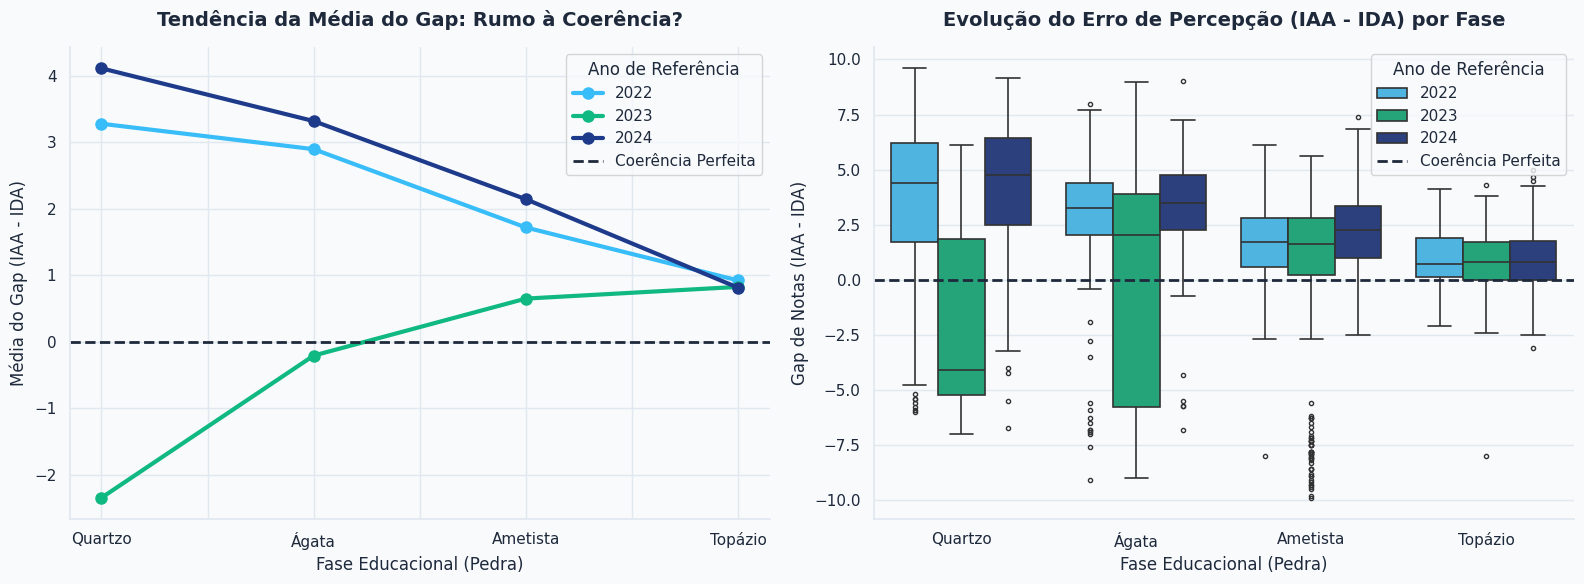

In [55]:
df['Pedra'] = df['Pedra'].astype(str).str.strip().str.title().replace({'Agata': 'Ágata'})
df['Gap_IDA'] = df['IAA'] - df['IDA']

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cores_anos = [paleta_passos["cor_6"], paleta_passos["cor_4"], paleta_passos["cor_1"]]


# Gráfico 1: Linha de Tendência (Média do Gap)
# Calcula a média do Gap por Pedra e Ano
tabela_gap_media = df.pivot_table(index='Pedra', columns='Ano_Referencia', values='Gap_IDA', aggfunc='mean')
tabela_gap_media = tabela_gap_media.reindex(index=pedras_presentes)

tabela_gap_media.plot(kind='line', marker='o', linewidth=3, markersize=8,
                      color=cores_anos, ax=axes[0])

# Linha do zero absoluto
axes[0].axhline(0, color=paleta_passos['texto'], linestyle='--', linewidth=2, label='Coerência Perfeita')

axes[0].set_title('Tendência da Média do Gap: Rumo à Coerência?',
                  fontsize=14, pad=15, weight='bold')
axes[0].set_xlabel('Fase Educacional (Pedra)', fontsize=12)
axes[0].set_ylabel('Média do Gap (IAA - IDA)', fontsize=12)
axes[0].legend(title='Ano de Referência', loc='upper right', frameon=True)

# Boxplot da Dispersão do Gap por Pedra
sns.boxplot(data=df, x='Pedra', y='Gap_IDA', hue='Ano_Referencia',
            order=pedras_presentes, palette=cores_anos, ax=axes[1],
            linewidth=1.2, fliersize=3)

# Linha do zero absoluto (onde IAA == IDA)
axes[1].axhline(0, color=paleta_passos['texto'], linestyle='--', linewidth=2, label='Coerência Perfeita')

axes[1].set_title('Evolução do Erro de Percepção (IAA - IDA) por Fase',
                  fontsize=14, pad=15, weight='bold')
axes[1].set_xlabel('Fase Educacional (Pedra)', fontsize=12)
axes[1].set_ylabel('Gap de Notas (IAA - IDA)', fontsize=12)
axes[1].legend(title='Ano de Referência', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

O gráfico de linhas da direita é a prova do impacto psicossocial do programa. As linhas de 2022 e 2024 começam no alto no Quartzo (alunos se superestimando em 3 ou 4 pontos) e descem consistentemente fase a fase, convergindo para a linha tracejada de Coerência Perfeita no Topázio.

A turma de 2023 chama a atenção por fazer o caminho inverso. Eles começaram no Quartzo se subestimando (por volta de -2.5 pontos) e foram ganhando confiança (subindo em direção ao zero) até convergirem junto com as outras safras no Topázio. Pode indicar alguma mudança metodológica na ONG naquele ano, com provas mais difíceis, por exemplo.

Já no boxplot à direita, a "caixa" do Topázio é a menor e mais compactada de todas as pedras. Isso consolida a tese de que os alunos veteranos desenvolvem uma autopercepção aderente e homogênea. Eles sabem com maior precisão o que dominam e onde estão falhando.

Os alunos da fase Ametista chamam a atenção com diversos outliers apontados para baixo (valores muito negativos, chegando a quase -10) em 2023, com a nota real (IDA) drasticamente maior que a autoavaliação (IAA). Esse comportamento pode indicar inseguranças nessa transição de nível, ou talvez de fato 2023 tenha sido um outlier nesse quesito, dado que a tendência da média do Gap também foi diferente para esse ano.

De forma geral, o programa eleva as notas e também calibra a autoconsciência da criança para a realidade.

###Qual a relação entre IAN e IPP?

 As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

 Por definição:

 IPP (Indicador Psicopedagógico) é uma dimensão psicossocial, resultado da avaliação de educadores e psicodagogos sobre o desenvolvimento cognitivo, amocional, comportamental e de socialização do aluno. Presente somente das fases 0 a 7.

 O indicador passa a existir na base de dados de 2023, portanto utilizaremos 2023 e 2024 como referência dessa análise.

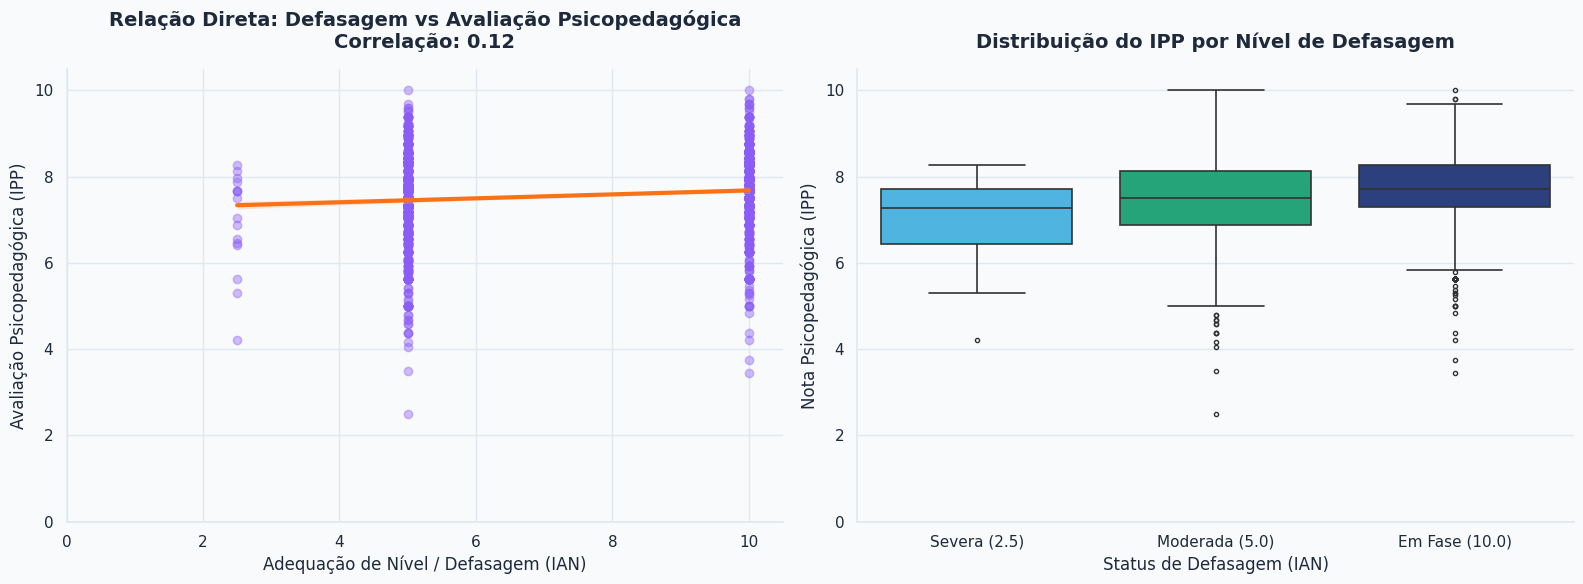

In [56]:
# Filtro de Ano (Garantindo que só teremos 2023 e 2024 para essa análise)
df_fase3 = df[df['Ano_Referencia'].isin([2023, 2024])].copy()

df_fase3['IAN_Desc'] = df_fase3['IAN'].map(dicionario_ian)

# Cálculo da Correlação de Pearson (ignorando os nulos)
df_corr = df_fase3[['IAN', 'IPP']].dropna()
correlacao = df_corr.corr().iloc[0, 1]

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Dispersão e Correlação (IAN vs IPP)
sns.regplot(data=df_fase3, x='IAN', y='IPP',
            scatter_kws={'alpha': 0.4, 'color': paleta_passos["cor_5"]},
            line_kws={'color': paleta_passos["cor_2"], 'linewidth': 3},
            ax=axes[0])

axes[0].set_title(f'Relação Direta: Defasagem vs Avaliação Psicopedagógica\nCorrelação: {correlacao:.2f}',
                  fontsize=14, pad=15, weight='bold')
axes[0].set_xlabel('Adequação de Nível / Defasagem (IAN)', fontsize=12)
axes[0].set_ylabel('Avaliação Psicopedagógica (IPP)', fontsize=12)
axes[0].set_xlim(0, 10.5)
axes[0].set_ylim(0, 10.5)

# Gráfico 2: Boxplot do IPP por Nível de Defasagem
sns.boxplot(data=df_fase3, x='IAN_Desc', y='IPP', order=ordem_ian,
            palette=[paleta_passos["cor_6"], paleta_passos["cor_4"], paleta_passos["cor_1"]],
            ax=axes[1], linewidth=1.2, fliersize=3)

axes[1].set_title('Distribuição do IPP por Nível de Defasagem',
                  fontsize=14, pad=15, weight='bold')
axes[1].set_xlabel('Status de Defasagem (IAN)', fontsize=12)
axes[1].set_ylabel('Nota Psicopedagógica (IPP)', fontsize=12)
axes[1].set_ylim(0, 10.5)

plt.tight_layout()
plt.show()

A correlação quase nula (0.12) é um atestado de imparcialidade, visto que os pedagogos não penalizam o aluno psicossocialmente (IPP) só porque ele carrega um atraso escolar. O desenvolvimento de aptidões, a socialização e a integração (avaliados no IPP) acontecem de forma independente do atraso educacional.

Olhando o Boxplot, a mediana do IPP para alunos com Defasagem Severa (IAN 2.5) continua alta, perto de 7.5. Isso demonstra que mesmo estando muito fora da fase ideal para a idade deles, os pedagogos captam esse engajamento humano e refletem isso em notas altas de IPP.

O que chama a atenção são as caixas e dispersão dos alunos em defasagem "Moderada" e "Em Fase". Existe uma boa quantidade outliers apontando para baixo.
Esses são alunos que estão na série perfeita para a idade deles (sem atraso nenhum), mas que estão com o desenvolvimento psicopedagógico (IPP) em níveis críticos. Eles podem estar enfrentando problemas familiares, isolamento social, falta de integração com a turma ou bloqueios emocionais, por exemplo.

A análise indica que o IPP complementa o IAN, iluminando pontos cegos e promovendo apoio aos alunos que possam estar passando por problemas que não o desempenho escolar.

### Aspectos Psicossociais (IPS) que antecedem quedas em desempenho ou engajamento

Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

Por definição:

IPS (Indicador Psicossocial) é uma dimensão psicossocial, parecida com o IPP, mas é uma avaliação realizada somente pelo time de psicólogos da Passos.

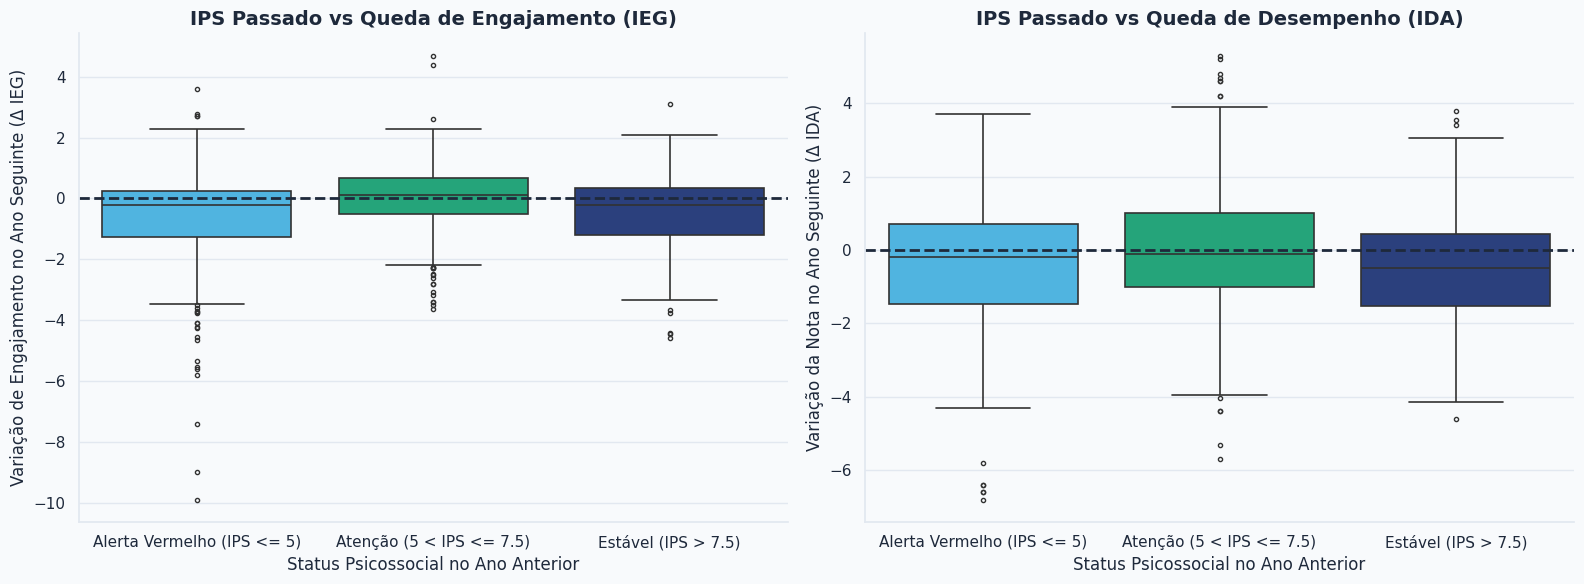

In [57]:
df_sorted = df_longitudinal.sort_values(by=['RA', 'Ano_Referencia']).copy()

# Pegar o IPS passado e a Variação (Delta) atual
df_sorted['IPS_Anterior'] = df_sorted.groupby('RA')['IPS'].shift(1)
df_sorted['Delta_IDA'] = df_sorted.groupby('RA')['IDA'].diff(1)
df_sorted['Delta_IEG'] = df_sorted.groupby('RA')['IEG'].diff(1)

# Filtramos os anos "base" (onde os deltas ficam nulos por não terem ano anterior)
df_tendencia = df_sorted.dropna(subset=['IPS_Anterior', 'Delta_IDA', 'Delta_IEG']).copy()

# 5. Criar categorias de "Risco" baseadas no IPS do ano anterior
def classificar_risco_ips(ips):
    if ips <= 5.0:
        return 'Alerta Vermelho (IPS <= 5)'
    elif ips <= 7.5:
        return 'Atenção (5 < IPS <= 7.5)'
    else:
        return 'Estável (IPS > 7.5)'

df_tendencia['Status_IPS_Passado'] = df_tendencia['IPS_Anterior'].apply(classificar_risco_ips)
ordem_risco = ['Alerta Vermelho (IPS <= 5)', 'Atenção (5 < IPS <= 7.5)', 'Estável (IPS > 7.5)']

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cores_risco = [paleta_passos["cor_6"], paleta_passos["cor_4"], paleta_passos["cor_1"]]

# Gráfico 1: O Impacto do IPS Passado no Engajamento (IEG) Futuro
sns.boxplot(data=df_tendencia, x='Status_IPS_Passado', y='Delta_IEG', order=ordem_risco,
            palette=cores_risco, ax=axes[0], linewidth=1.2, fliersize=3)

axes[0].axhline(0, color=paleta_passos["texto"], linestyle='--', linewidth=2)
axes[0].set_title('IPS Passado vs Queda de Engajamento (IEG)', fontsize=14, weight='bold')
axes[0].set_xlabel('Status Psicossocial no Ano Anterior', fontsize=12)
axes[0].set_ylabel('Variação de Engajamento no Ano Seguinte (Δ IEG)', fontsize=12)

# Gráfico 2: O Impacto do IPS Passado no Desempenho (IDA) Futuro
sns.boxplot(data=df_tendencia, x='Status_IPS_Passado', y='Delta_IDA', order=ordem_risco,
            palette=cores_risco, ax=axes[1], linewidth=1.2, fliersize=3)

axes[1].axhline(0, color=paleta_passos["texto"], linestyle='--', linewidth=2)
axes[1].set_title('IPS Passado vs Queda de Desempenho (IDA)', fontsize=14, weight='bold')
axes[1].set_xlabel('Status Psicossocial no Ano Anterior', fontsize=12)
axes[1].set_ylabel('Variação da Nota no Ano Seguinte (Δ IDA)', fontsize=12)

plt.tight_layout()
plt.show()

No gráfico à esquerda, existem diversos outliers com notas de engajamento entre -4 e -10, indicando que os alunos com IPS <= 5 no ano anterior tem uma probabilidade altíssima de abandonar o engajamento no ano seguinte. É um indicativo valioso de que o IPS baixo é o maior preditor de evasão (churn) do programa.

No gráfico da direita (IDA), a caixa do Alerta Vermelho também mostra uma tendência de queda de notas, com outliers batendo -4 e -6 pontos no ano seguinte. Isso fecha o ciclo da nossa hipótese anterior: a criança sofre um abalo emocional/psicossocial (indicado pelo IPS <=5), engajamento cai e queda abrupta nas notas (IDA).

###Métricas com maior peso na composição do INDE

Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

O INDE é composto por:
Fases 0 a 7
IAN x 0,1 + IDA x 0,2 + IEG x 0,2 + IAA x 0,1 + IPS x 0,1 + IPP x 0,1 + IPV x 0,2

Fase 8
IAN x 0,1 + IDA x 0,4 + IEG x 0,2 + IAA x 0,1 + IPS x 0,2

Como a análise envolve os dados de IPP, presentes somente a partir de 2023, aplicaremos a restrição temporal no dataframe.

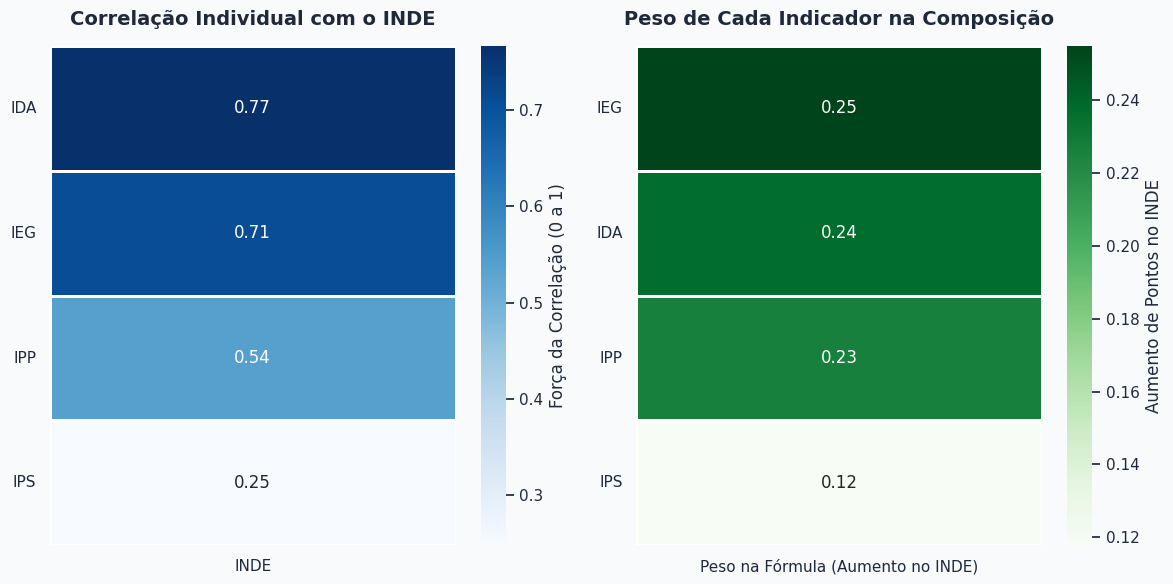

In [58]:
# Filtro de Ano (Garantindo apenas a janela onde o IPP existe)
df_fase5 = df[df['Ano_Referencia'].isin([2023, 2024])].copy()

# 2. Tratamento de Segurança das variáveis
colunas_modelo = ['IDA', 'IEG', 'IPS', 'IPP', 'INDE']

# Remover nulos (Modelos matemáticos não aceitam valores vazios)
df_modelo = df_fase5[colunas_modelo].dropna()

# Cálculo das Correlações Individuais Diretas com o INDE
correlacoes = df_modelo.corr()[['INDE']].drop('INDE').sort_values(by='INDE', ascending=False)

# 5. Modelo de Regressão Linear Múltipla (Para achar o "Peso" da combinação)
X = df_modelo[['IDA', 'IEG', 'IPS', 'IPP']]
y = df_modelo['INDE']

modelo = LinearRegression()
modelo.fit(X, y)

# Criando um DataFrame com os coeficientes da regressão
coeficientes = pd.DataFrame({
    'Indicador': X.columns,
    'Peso na Fórmula (Aumento no INDE)': modelo.coef_
}).sort_values(by='Peso na Fórmula (Aumento no INDE)', ascending=False)

coeficientes = coeficientes.set_index('Indicador')

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Heatmap 1: Correlação Isolada
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="Blues",
            cbar_kws={'label': 'Força da Correlação (0 a 1)'},
            linewidths=2, linecolor='white', ax=axes[0])

axes[0].set_title('Correlação Individual com o INDE', fontsize=14, pad=15, weight='bold')
axes[0].set_ylabel('') # Remove o nome do eixo
axes[0].tick_params(axis='y', rotation=0)

# Heatmap 2: O Peso Real na Combinação (Regressão)
sns.heatmap(coeficientes, annot=True, fmt=".2f", cmap="Greens",
            cbar_kws={'label': 'Aumento de Pontos no INDE'},
            linewidths=2, linecolor='white', ax=axes[1])

axes[1].set_title('Peso de Cada Indicador na Composição', fontsize=14, pad=15, weight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

No mapa azul de correlação, IDA (0.77) e IEG (0.71) realmente dominam as correlações isoladas. Mas analisando em conjunto o mapa de peso de cada indicador, IEG (0.25), IDA (0.24) e IPP (0.23) possuem pesos praticamente idênticos na alavancagem da nota global, quando combinados.

O IPS possui a menor correlação isolada (0.25) e exatamente metade do peso dos outros indicadores na composição final (0.12).Dessa forma, o status psicossocial atua como um suporte indireto.

Tanto para IPS, quanto para IDA e IEG, o modelo estatístico "adivinhou" a regra de negócio, com pesos muito próximos aos que o cálculo do indicador INDE traz.

Enquanto a fórmula oficial atribui um peso de 10% ao IPP, o modelo de regressão capturou um impacto real de 23% na composição do INDE. Este salto ocorre devido ao indicador IPV (que possui peso oficial de 20%) ter sido omitido deste recorte e medir comportamentos altamente correlacionados ao IPP; portanto, o algoritmo transferiu o crédito desse impacto para a variável presente.

###Isolamento de Ponto de Virada (IPV)

Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

Para isso, vamos comparar o IPV com IEG (engajamento), IPP (desenvolvimento emocional) e IDA (performance acadêmica).

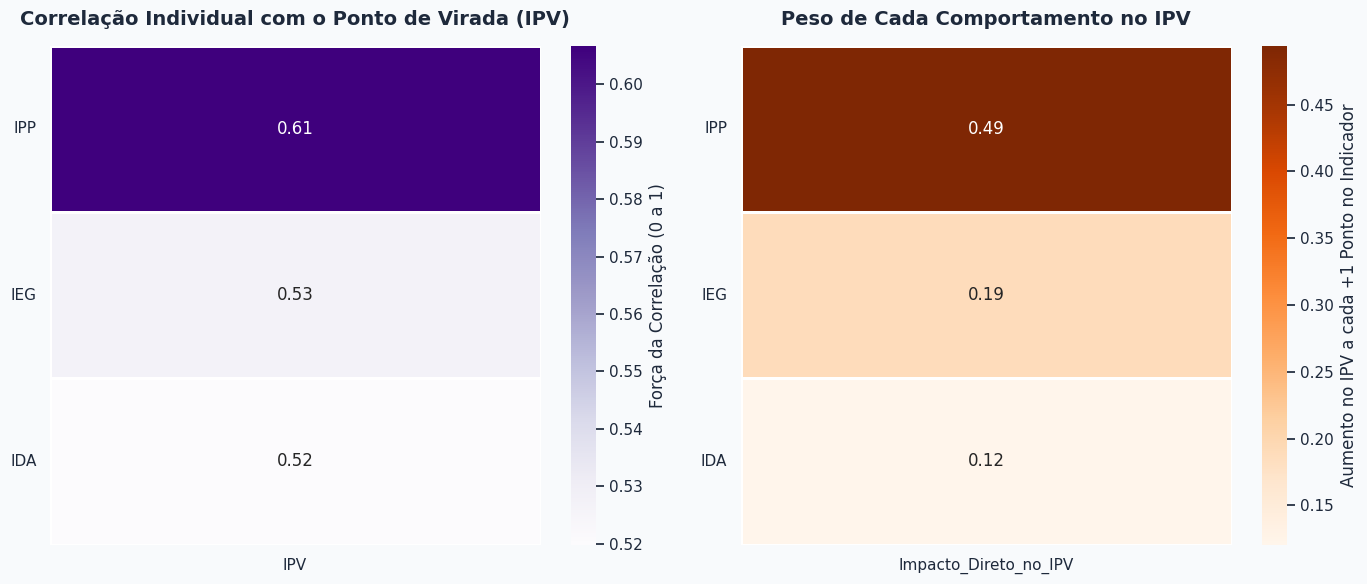

In [59]:
# Filtro de Ano (Garantindo a janela de 2023 e 2024)
df_fase_final = df[df['Ano_Referencia'].isin([2023, 2024])].copy()

colunas_alvo = ['IPV', 'IPP', 'IDA', 'IEG']

df_modelo_ipv = df_fase_final[colunas_alvo]

# Cálculo das Correlações Individuais Diretas com o IPV
correlacoes_ipv = df_modelo_ipv.corr()[['IPV']].drop('IPV').sort_values(by='IPV', ascending=False)

# Modelo de Regressão Linear Múltipla (O que "puxa" o IPV na prática?)
X_ipv = df_modelo_ipv[['IPP', 'IDA', 'IEG']]
y_ipv = df_modelo_ipv['IPV']

modelo_ipv = LinearRegression()
modelo_ipv.fit(X_ipv, y_ipv)

# Criando DataFrame com os coeficientes da regressão
coeficientes_ipv = pd.DataFrame(
    modelo_ipv.coef_,
    index=X_ipv.columns,
    columns=['Impacto_Direto_no_IPV']
).sort_values(by='Impacto_Direto_no_IPV', ascending=False)

# PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap 1: Correlação Isolada
sns.heatmap(correlacoes_ipv, annot=True, fmt=".2f", cmap="Purples",
            cbar_kws={'label': 'Força da Correlação (0 a 1)'},
            linewidths=2, linecolor='white', ax=axes[0])

axes[0].set_title('Correlação Individual com o Ponto de Virada (IPV)', fontsize=14, pad=15, weight='bold')
axes[0].set_ylabel('')
axes[0].tick_params(axis='y', rotation=0)

# Heatmap 2: O Peso Real na Combinação (Regressão Múltipla)
sns.heatmap(coeficientes_ipv, annot=True, fmt=".2f", cmap="Oranges",
            cbar_kws={'label': 'Aumento no IPV a cada +1 Ponto no Indicador'},
            linewidths=2, linecolor='white', ax=axes[1])

axes[1].set_title('Peso de Cada Comportamento no IPV', fontsize=14, pad=15, weight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

Enquanto no mapa azul (esquerda) as correlações parecem próximas, no mapa laranja (direita) a regressão isolou o impacto de cada variável e provou que o IPP (0.49) domina a composição do Ponto de Virada (IPP).

O impacto do desenvolvimento psicopedagógico é mais do que o dobro do impacto do engajamento (0.19) e quatro vezes maior que o da nota técnica (0.12). Isso indica que a "virada" é uma transformação emocional e de maturidade, muito mais multidisciplinar do que somente a melhora de suas notas.

O Engajamento fica no segundo lugar de importância para o IPV, com 0.19,demonstrando que quando o aluno passa por essa transformação, ele passa a entregar as lições de casa e a se envolver ativamente nas atividades voluntárias da instituição.

O IDA ficou com o menor peso de influência direta (0.12). A evolução nas notas parece ser o último estágio de uma criança que já está passando por transformação na sua postura e se desenvolvendo emocionalmente.

###Ideias de perguntas extra
Alunos que entram antes no programa tem um INDE mais íngreme e sustentável ao longo dos anos?
Clusterização de personas - existem perfis "ocultos" de alunos?
Gargalos de Fase: Existe uma transição de fase específica (ex: do Fundamental para o Ensino Médio / de Ametista para Topázio) onde a queda de desempenho ou engajamento é estatisticamente mais comum?
Resiliência (Tempo de Recuperação): Quando um aluno sofre uma queda brusca no indicador psicossocial (IPS), quantos ciclos demoram, em média, para os indicadores acadêmicos se estabilizarem novamente?

###

## Hipóteses Analíticas Iniciais

1. A análise gráfica da evolução do indicador IAN ao longo dos anos aponta uma efetividade da intervenção da Passos Mágicos, de forma que:
Tanto a porcentagem de alunos em defasagem severa, quanto em defasagem moderada diminuíram ao longo do tempo; o que também significa um aumento de 30,12 para 49,34% dos alunos em fase.

2. Os dados provam o sucesso da ONG: a mobilidade ascendente (159 alunos melhoraram) é muito maior que a mobilidade descendente (30 alunos pioraram). O principal desafio futuro da instituição não é mais resgatar alunos em estado crítico, mas sim destravar os 128 alunos que estão estagnados no nível "Moderado".